## Create three ansatze with different rotations that cover the Bloch sphere space.

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli

theta = Parameter("θ")
phi = Parameter("φ")
lam = Parameter("λ")

ansatz1 = QuantumCircuit(1)
ansatz1.rx(theta, 0)

ansatz2 = QuantumCircuit(1)
ansatz2.rx(theta, 0)
ansatz2.rz(phi, 0)

ansatz3 = QuantumCircuit(1)
ansatz3.rx(theta, 0)
ansatz3.rz(phi, 0)
ansatz3.rx(lam, 0)

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bloch(bloch_vectors):
    # Extract X, Y, Z coordinates for 3D projection
    X_coords = bloch_vectors[:, 0]
    Z_coords = bloch_vectors[:, 2]
    
    Y_coords = bloch_vectors[:, 1]
    
    # Create 3D plot
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection = "3d")
    ax.scatter(X_coords, Y_coords, Z_coords, color="blue", alpha = 0.6)
    
    # Labels and title
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Parametrized 1-Qubit Circuit on 3D Bloch Sphere")
    
    # Set axis limits and make them equal
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    
    # Ensure equal aspect ratio for all axes
    ax.set_box_aspect([1, 1, 1])
    
    # Show grid
    ax.grid(True)
    
    plt.show()
    
num_samples = 5000  # Number of random states
theta_vals = np.random.uniform(0, 2 * np.pi, num_samples)
phi_vals = np.random.uniform(0, 2 * np.pi, num_samples)
lam_vals = np.random.uniform(0, 2 * np.pi, num_samples)

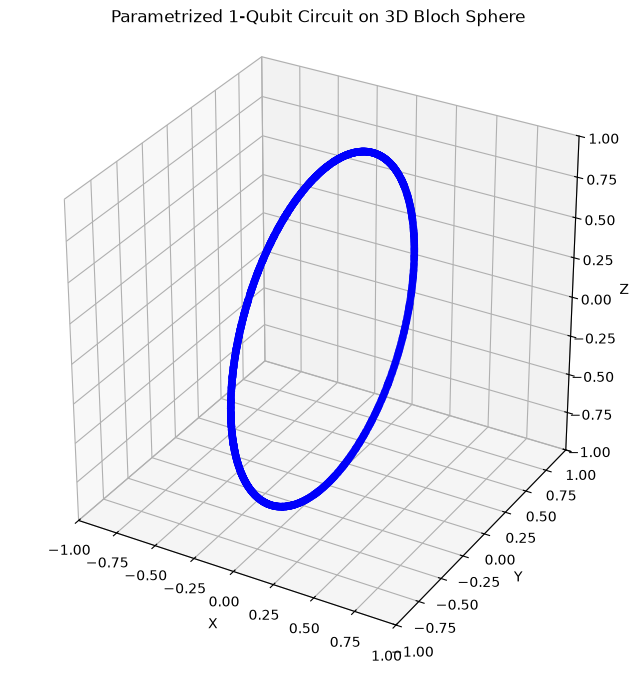

In [6]:
# List to store Bloch sphere XZ coordinates
bloch_vectors = []

# Generate quantum states and extract Bloch vectors
for i in range(num_samples):
    # Create a circuit and bind parameters
    qc = ansatz1
    bound_qc = qc.assign_parameters({theta: theta_vals[i]})
    state = Statevector.from_instruction(bound_qc)
    rho = DensityMatrix(state)
    
    X = rho.expectation_value(Pauli("X")).real
    Y = rho.expectation_value(Pauli("Y")).real
    Z = rho.expectation_value(Pauli("Z")).real
    bloch_vectors.append([X, Y, Z])     # Store Bloch sphere coordinates

# Convert to a numpy array for plotting
bloch_vectors= np.array(bloch_vectors)

plot_bloch(bloch_vectors)
    

As expected, our first ansatz has retrieved a ring shaped distribution as there is only one rotation parameter.

### Ansatz2

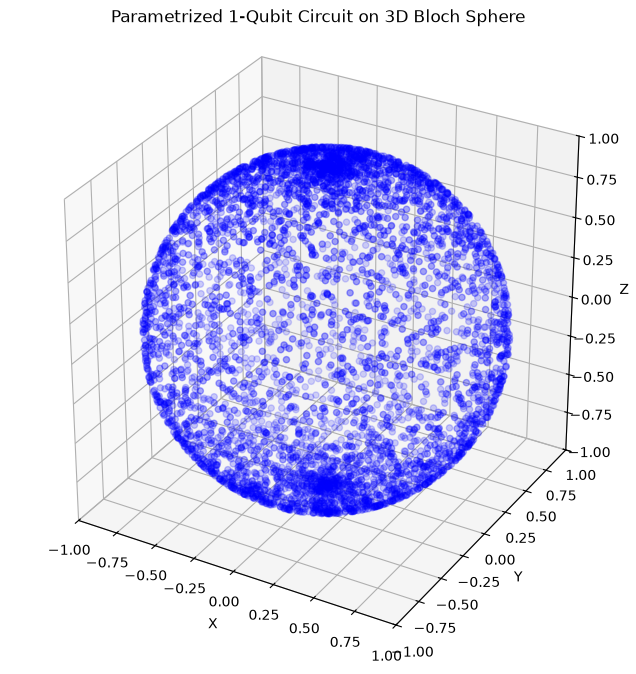

In [7]:
# List to store Bloch sphere XZ coordinates
bloch_vectors = []

# Generate quantum states and extract Bloch vectors
for i in range(num_samples):
    # Create a circuit and bind parameters
    qc = ansatz2
    bound_qc = qc.assign_parameters({theta: theta_vals[i], phi: phi_vals[i]})
    state = Statevector.from_instruction(bound_qc)
    rho = DensityMatrix(state)
    
    X = rho.expectation_value(Pauli("X")).real
    Y = rho.expectation_value(Pauli("Y")).real
    Z = rho.expectation_value(Pauli("Z")).real
    bloch_vectors.append([X, Y, Z])     # Store Bloch sphere coordinates

# Convert to a numpy array for plotting
bloch_vectors= np.array(bloch_vectors)

plot_bloch(bloch_vectors)
    

Note that more points are covered near the poles and hence it does not cover uniformly.

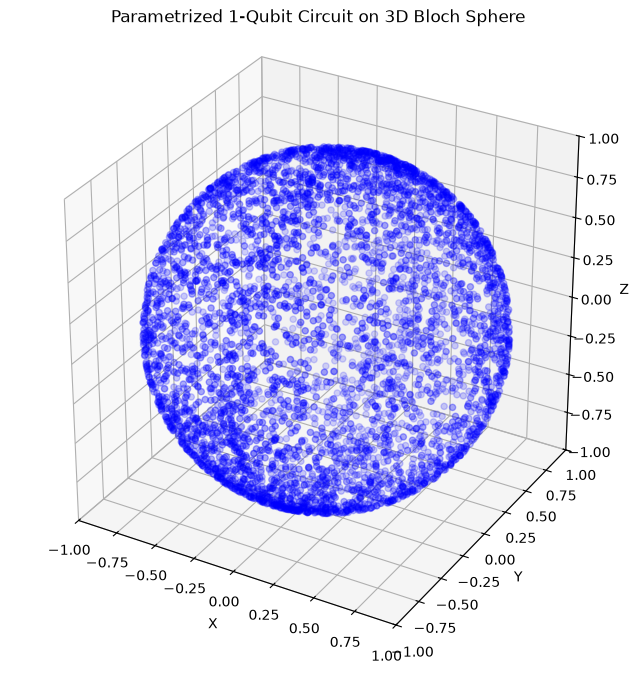

In [9]:
# List to store Bloch sphere XZ coordinates
bloch_vectors = []

# Generate quantum states and extract Bloch vectors
for i in range(num_samples):
    # Create a circuit and bind parameters
    qc = ansatz3
    bound_qc = qc.assign_parameters({theta: theta_vals[i], phi: phi_vals[i], lam: lam_vals[i]})
    state = Statevector.from_instruction(bound_qc)
    rho = DensityMatrix(state)
    
    X = rho.expectation_value(Pauli("X")).real
    Y = rho.expectation_value(Pauli("Y")).real
    Z = rho.expectation_value(Pauli("Z")).real
    bloch_vectors.append([X, Y, Z])     # Store Bloch sphere coordinates

# Convert to a numpy array for plotting
bloch_vectors= np.array(bloch_vectors)

plot_bloch(bloch_vectors)
    

## Transpile

In [11]:
from qiskit_ibm_runtime import QiskitRuntimeService

from qiskit_ibm_runtime import EstimatorV2 as Estimator

service = QiskitRuntimeService()

backend = service.least_busy(operational = True, simulator = False, min_num_qubits = 127)
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-09-23 17:11:56,414: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-23 17:11:57,229: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-23 17:12:01,526: Using instance: open-instance, plan: open


ibm_fez


Backend: {config.backend_name}
Native gates:  ['cz', 'id', 'delay', 'measure', 'measure_reset', 'measure_2', 'measure_reset_2', 'reset', 'reset_2', 'rz', 'sx', 'x', 'if_else', 'store', 'xslow'] ,


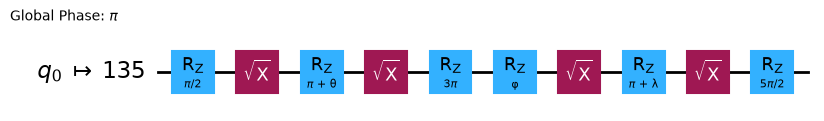

In [12]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

config = backend.configuration()

print("Backend: {config.backend_name}")
print("Native gates: ", config.supported_instructions, ",")

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

ansatz_isa = pm.run(ansatz3)
ansatz_isa.draw("mpl", idle_wires = False, style = "iqp")

The Hamiltonian for our problem (H2 molecule ground state energy estimation) and mapping to the new layout.

In [13]:
from qiskit.quantum_info import SparsePauliOp
Hamiltonian = SparsePauliOp.from_list([("I", -0.2355), ("Z", 0.2355)])
Hamiltonian_isa = Hamiltonian.apply_layout(layout = ansatz_isa.layout)

In [12]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """ Return estimate of energy from estimator
    Parameters: 
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results
        
    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs= [pub]).result()
    energy = result[0].data.evs[0]
    
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")
    
    return energy

In [16]:
x0 = [1, 1, 0]      # Choose initial parameters randomly

In [17]:
from scipy.optimize import minimize
from qiskit_ibm_runtime import Batch

batch = Batch(backend= backend)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": []
}
estimator = Estimator(mode= batch)
estimator.options.default_shots = 10000

res = minimize(
    cost_func,
    x0,
    args = (ansatz_isa, Hamiltonian_isa, estimator),
    method = "cobyla",
    options = {"maxiter": 10, "tol": 0.01},
)

batch.close()

Iters. done: 1 [Current cost: -0.3233234710803823]
Iters. done: 2 [Current cost: -0.4647757397230816]
Iters. done: 3 [Current cost: -0.39907935669883676]
Iters. done: 4 [Current cost: -0.3853472722473646]
Iters. done: 5 [Current cost: -0.4587127096382768]
Iters. done: 6 [Current cost: -0.4009733574545711]
Iters. done: 7 [Current cost: -0.46324608574035353]
Iters. done: 8 [Current cost: -0.46431152301850465]
Iters. done: 9 [Current cost: -0.47244931291571785]
Iters. done: 10 [Current cost: -0.46931272923852474]


In [19]:
A = np.array(Hamiltonian)
eigenvalues, eigenvectors = np.linalg.eig(A)
h = min(eigenvalues.real)

h_vqe = res.fun
print("The reference ground state energy is ", min(eigenvalues))
print("The computed ground state energy is", h_vqe)

The reference ground state energy is  (-0.471+0j)
The computed ground state energy is -0.47244931291571785


###Post-process

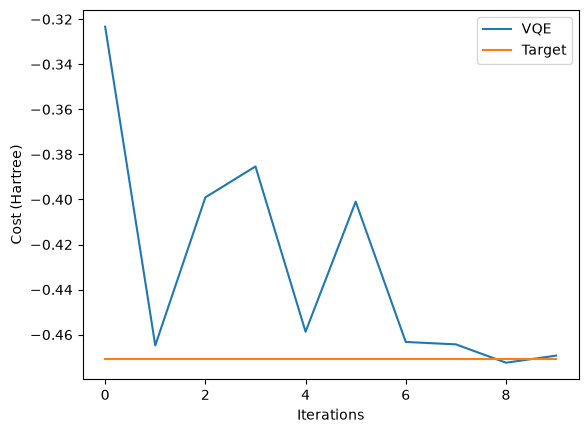

In [20]:
fig, ax = plt.subplots()
x = np.linspace(0, 10, 10)

# Define the constant function
y_constant = np.full_like(x, h)
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label ="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (Hartree)")
ax.plot(y_constant, label = "Target")
plt.legend()
plt.draw()

# Ground state energy of Hydrogen molecule

In [21]:
h2_hamiltonian = SparsePauliOp.from_list([("I", -1.04886087), ("Z", -0.7967368), ("X", 0.18121804)])

# exact ground state energy of hamiltonian
nuclear_repulsion = 0.71997
A = np.array(h2_hamiltonian)
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Electronic ground state energy (Hartree): ", min(eigenvalues).real)
print("Nuclear repulsion energy (Hartree): ", nuclear_repulsion)
print(
    "Total ground state energy (Hartree): ", min(eigenvalues).real + nuclear_repulsion
)
h2 = min(eigenvalues).real + nuclear_repulsion

Electronic ground state energy (Hartree):  -1.8659468547627318
Nuclear repulsion energy (Hartree):  0.71997
Total ground state energy (Hartree):  -1.1459768547627318


In [22]:
h2_hamiltonian_isa = h2_hamiltonian.apply_layout(layout= ansatz_isa.layout)

In [23]:
x0 = [2, 0, 0]      # We can also use a random variable
# x0 = np.random.uniform(0, 2*pi, 3)

In [24]:
batch = Batch(backend=backend)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
estimator = Estimator(mode=batch)
estimator.options.default_shots = 10000

res = minimize(
    cost_func,
    x0,
    args= (ansatz_isa, h2_hamiltonian_isa, estimator),
    method = "cobyla",
    options = {"maxiter": 15},
)

batch.close()

Iters. done: 1 [Current cost: -0.7464984718726102]
Iters. done: 2 [Current cost: -0.26755484939639007]
Iters. done: 3 [Current cost: -0.26962405972856845]
Iters. done: 4 [Current cost: -0.591708020624814]
Iters. done: 5 [Current cost: -1.7331943558546554]
Iters. done: 6 [Current cost: -0.67626548602456]
Iters. done: 7 [Current cost: -1.5030021768301998]
Iters. done: 8 [Current cost: -1.8639808827812407]
Iters. done: 9 [Current cost: -1.8293193796779283]
Iters. done: 10 [Current cost: -1.8538674659995047]
Iters. done: 11 [Current cost: -1.7813640372023318]
Iters. done: 12 [Current cost: -1.862571125702552]
Iters. done: 13 [Current cost: -1.8670437088647054]
Iters. done: 14 [Current cost: -1.863999595416811]
Iters. done: 15 [Current cost: -1.874225292737499]


In [25]:
h2_vqe = res.fun + nuclear_repulsion
print("The reference ground state energy is ", min(eigenvalues).real + nuclear_repulsion)
print("The computed ground state energy is ", h2_vqe)

The reference ground state energy is  -1.1459768547627318
The computed ground state energy is  -1.154255292737499


c:\Users\AmritRaj\anaconda3\envs\env1\Lib\site-packages\numpy\_core\numeric.py:475: ComplexWarning: Casting complex values to real discards the imaginary part
  multiarray.copyto(res, fill_value, casting='unsafe')


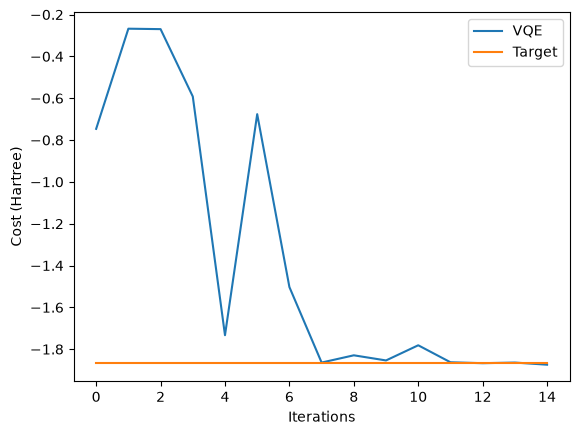

In [27]:
fig, ax = plt.subplots()
x = np.linspace(0, 5, 15)

# Define the constant function
y_constant = np.full_like(x, min(eigenvalues))
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label = "VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (Hartree)")
ax.plot(y_constant, label = "Target")
plt.legend()
plt.draw()

# Reaction Energy of $H + H = H_2$

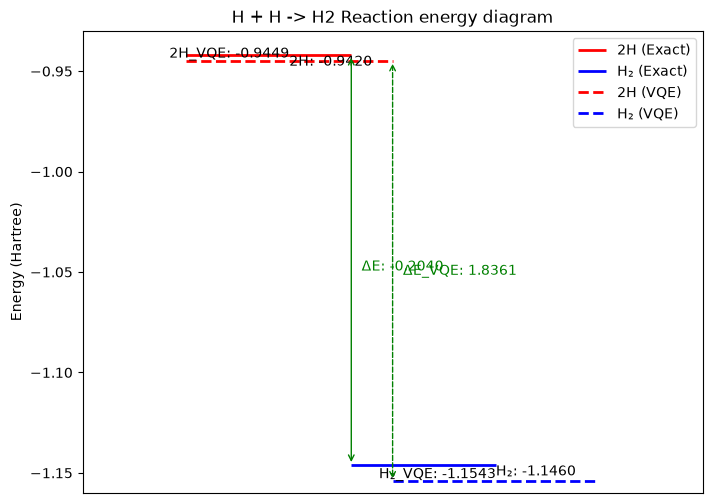

In [28]:
# Theoretical values
E_H_theo = h.real
E_H2_theo = h2

# Experimental values
E_H_exp = h_vqe
E_H2_exp = h2_vqe

# Calculate reaction energies
E_reaction_theo = E_H2_theo - (2*E_H_theo)
E_reaction_exp = E_H_exp - (2*E_H2_exp)

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 3)
ax.set_ylim(-1.16, -0.93)
ax.set_xticks([])
ax.set_ylabel("Energy (Hartree)")
ax.set_title("H + H -> H2 Reaction energy diagram")

# Plot theoretical enregy levels
ax.hlines(
    y=2 * E_H_theo, xmin=0.5, xmax=1.3, linewidth=2, color="r", label="2H (Exact)"
)
ax.hlines(y=E_H2_theo, xmin=1.3, xmax=2, linewidth=2, color="b", label="H₂ (Exact)")

# Plot experimental energy levels
ax.hlines(
    y=2 * E_H_exp,
    xmin=0.5,
    xmax=1.5,
    linewidth=2,
    color="r",
    linestyle="dashed",
    label="2H (VQE)",
)
ax.hlines(
    y=E_H2_exp,
    xmin=1.5,
    xmax=2.5,
    linewidth=2,
    color="b",
    linestyle="dashed",
    label="H₂ (VQE)",
)

# Add labels
ax.text(
    1,
    2 * E_H_theo,
    f"2H: {2*E_H_theo:.4f}",
    verticalalignment="top",
    horizontalalignment="left",
)
ax.text(
    2,
    E_H2_theo,
    f"H₂: {E_H2_theo:.4f}",
    verticalalignment="top",
    horizontalalignment="left",
)
ax.text(
    1,
    2 * E_H_exp,
    f"2H_VQE: {2*E_H_exp:.4f}",
    verticalalignment="bottom",
    horizontalalignment="right",
)
ax.text(
    2,
    E_H2_exp,
    f"H₂_VQE: {E_H2_exp:.4f}",
    verticalalignment="bottom",
    horizontalalignment="right",
)

# Add arrows for reaction energy with ΔE label in the middle
mid_y_theo = (2 * E_H_theo + E_H2_theo) / 2
mid_y_exp = (2 * E_H_exp + E_H2_exp) / 2
ax.annotate(
    "",
    xy=(1.3, E_H2_theo),
    xytext=(1.3, 2 * E_H_theo),
    arrowprops=dict(arrowstyle="<->", color="g"),
)
ax.text(
    1.35, mid_y_theo, f"ΔE: {E_reaction_theo:.4f}", color="g", verticalalignment="top"
)

ax.annotate(
    "",
    xy=(1.5, E_H2_exp),
    xytext=(1.5, 2 * E_H_exp),
    arrowprops=dict(arrowstyle="<->", color="g", linestyle="dashed"),
)
ax.text(
    1.55,
    mid_y_exp,
    f"ΔE_VQE: {E_reaction_exp:.4f}",
    color="g",
    verticalalignment="center",
)

# Add legend
ax.legend()

plt.show()

# Additional Example: Using Different Ansatze 

In [3]:
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp

num_iter = 4
alpha = ParameterVector("alpha", 3)
beta = ParameterVector("beta", 3 * num_iter)

# step 1: Map Problem to quantum circuits and operators
hamiltonian = SparsePauliOp.from_list([("I", -1.04886087), ("Z", -0.7967368), ("X", 0.18121804)])

ansatz_1 = ansatz3
ansatz_2 = QuantumCircuit(1)
for i in range(num_iter):
    ansatz_2.rx(beta[i * 3 + 0], 0)
    ansatz_2.rz(beta[i * 3 + 1], 0)
    ansatz_2.rx(beta[i * 3 + 2], 0)

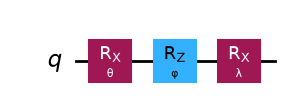

In [4]:
ansatz_1.draw("mpl")

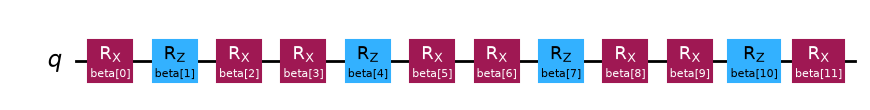

In [5]:
ansatz_2.draw("mpl")

In [6]:
# Use a simulator in case of no time available in real hardware
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(operational = True, simulator = False, min_num_qubits= 127)

noise_model = NoiseModel.from_backend(backend)
backend_sim = AerSimulator(noise_model= noise_model)

qiskit_runtime_service.__init__:WARNING:2026-09-24 11:02:40,328: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-24 11:02:41,970: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-24 11:02:49,446: Using instance: open-instance, plan: open


In [7]:
print(backend.name)

ibm_kingston


In [8]:
# Step 2: Optimize for target hardware
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend_sim.target
pm = generate_preset_pass_manager(target = target, optimization_level= 3)

ansatz_isa_1 = pm.run(ansatz_1)
ansatz_isa_2 = pm.run(ansatz_2)
hamiltonian_isa_1 = hamiltonian.apply_layout(ansatz_isa_1.layout)
hamiltonian_isa_2 = hamiltonian.apply_layout(ansatz_isa_2.layout)

#Ansatz 1

In [13]:
# Step 3: Execute on Real Hardware Simulator
from scipy.optimize import minimize
from qiskit_ibm_runtime import Batch
import numpy as np
from qiskit_ibm_runtime import EstimatorV2 as Estimator

x0 = np.ones(ansatz_1.num_parameters)

batch = Batch(backend= backend_sim)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
estimator = Estimator(mode = batch)
estimator.options.default_shots = 2048

res = minimize(
    cost_func,
    x0,
    args = (ansatz_isa_1, hamiltonian_isa_1, estimator),
    method = "cobyla",
    options = {"maxiter": 20}
)

batch.close()

Iters. done: 1 [Current cost: -0.8361556304294777]
Iters. done: 2 [Current cost: -0.4363073921473889]
Iters. done: 3 [Current cost: -0.43879288868228394]
Iters. done: 4 [Current cost: -1.3546144144997558]
Iters. done: 5 [Current cost: -1.7609919204050757]
Iters. done: 6 [Current cost: -1.538183801283553]
Iters. done: 7 [Current cost: -1.327639089170327]
Iters. done: 8 [Current cost: -1.7981925925768667]
Iters. done: 9 [Current cost: -1.735563239838946]
Iters. done: 10 [Current cost: -1.7920412702147388]
Iters. done: 11 [Current cost: -1.7922577852757442]
Iters. done: 12 [Current cost: -1.7905590876085897]
Iters. done: 13 [Current cost: -1.759863506544656]
Iters. done: 14 [Current cost: -1.7937033756320155]
Iters. done: 15 [Current cost: -1.7758075385993168]
Iters. done: 16 [Current cost: -1.793349606886286]
Iters. done: 17 [Current cost: -1.8068904422205954]
Iters. done: 18 [Current cost: -1.7872318383357735]
Iters. done: 19 [Current cost: -1.8042432535041484]
Iters. done: 20 [Current 

In [14]:
ansatz_1_history = cost_history_dict["cost_history"]

# Ansatz_2

In [15]:
# Step 3: Execute on Real Hardware Simulator
from scipy.optimize import minimize
from qiskit_ibm_runtime import Batch
import numpy as np
from qiskit_ibm_runtime import EstimatorV2 as Estimator

x0 = np.ones(ansatz_2.num_parameters)

batch = Batch(backend= backend_sim)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
estimator = Estimator(mode = batch)
estimator.options.default_shots = 2048

res = minimize(
    cost_func,
    x0,
    args = (ansatz_isa_2, hamiltonian_isa_2, estimator),
    method = "cobyla",
    options = {"maxiter": 20}
)

batch.close()

Iters. done: 1 [Current cost: -0.7720562488384577]
Iters. done: 2 [Current cost: -0.43776513625671054]
Iters. done: 3 [Current cost: -1.3486369380722305]
Iters. done: 4 [Current cost: -0.9156044527623229]
Iters. done: 5 [Current cost: -0.8838566807759881]
Iters. done: 6 [Current cost: -0.7298662219765739]
Iters. done: 7 [Current cost: -1.5271441786383604]
Iters. done: 8 [Current cost: -1.6187612994582723]
Iters. done: 9 [Current cost: -1.2459548391752073]
Iters. done: 10 [Current cost: -1.1530694053440702]
Iters. done: 11 [Current cost: -1.1752684596339678]
Iters. done: 12 [Current cost: -1.78155304579307]
Iters. done: 13 [Current cost: -1.267040671795998]
Iters. done: 14 [Current cost: -1.6562880014592483]
Iters. done: 15 [Current cost: -1.8036089005124452]
Iters. done: 16 [Current cost: -1.3916495701073692]
Iters. done: 17 [Current cost: -1.769802585236701]
Iters. done: 18 [Current cost: -1.3487711533186921]
Iters. done: 19 [Current cost: -1.807866279214251]
Iters. done: 20 [Current 

In [16]:
ansatz_2_history = cost_history_dict["cost_history"]

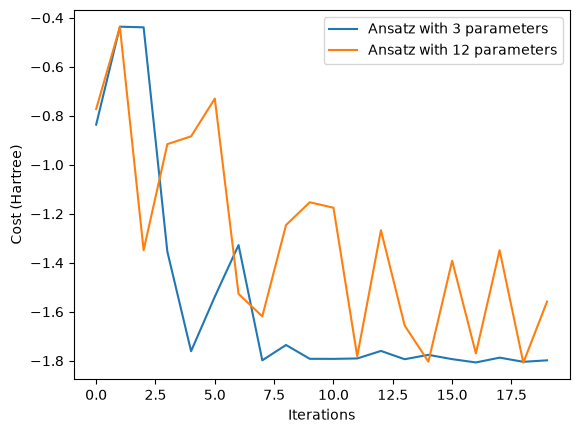

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Define the constant function
ax.plot(
    range(cost_history_dict["iters"]),
    ansatz_1_history,
    label = "Ansatz with 3 parameters",
)
ax.plot(
    range(cost_history_dict["iters"]),
    ansatz_2_history,
    label = "Ansatz with 12 parameters",
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (Hartree)")
plt.legend()
plt.draw()